# **Ferritin Levels in US Women Aged 18–49**
### NHANES 2021–2023 Analysis


## 1. Introduction

Ferritin is a blood protein that reflects the body’s iron stores. Structurally, ferritin forms a protein shell that can store up to approximately 4,500 iron atoms in its central cavity. Adequate iron levels are essential for energy metabolism, cognitive performance, oxygen transport, and overall health.
Women of reproductive age are particularly vulnerable to low iron stores due to menstruation, pregnancy, and increased physiological iron demands.
Globally, iron deficiency remains a major public health concern: the World Health Organization (WHO) estimates that 42% of children under 5 years of age and 40% of pregnant women are anaemic. Iron deficiency, haemoglobinopathies, and malaria are considered the three top causes of anaemia worldwide (WHO, 2021).


Laboratory reference ranges often define iron deficiency at ferritin levels below 10–15 µg/L. However, clinical literature suggests that iron stores may already be depleted below 30 µg/L, even in the absence of anemia. This analysis aims to examine ferritin levels in US women aged 18–49 using NHANES 2021–2023 data and to estimate how iron stores are distributed at the population level.

Ferritin is influenced by inflammation and physiological factors, so results should be interpreted in context.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

ferritin_df = pd.read_sas("/content/FERTIN_L.xpt")


In [13]:
ferritin_df.head()

,SEQN,WTPH2YR,LBXFER,LBDFERSI
0,130380.0,8.532884e+04,13.3,13.3
1,130381.0,5.397605e-79,NaN,NaN
2,130382.0,5.963893e+04,24.4,24.4
3,130388.0,3.286429e+04,NaN,NaN
4,130390.0,6.142701e+04,52.1,52.1


In [14]:
ferritin_df.describe()

,SEQN,WTPH2YR,LBXFER,LBDFERSI
count,2564.000000,2.564000e+03,1950.000000,1950.000000
mean,136369.672387,3.885291e+04,55.713882,55.713882
std,3451.322818,3.555767e+04,61.955185,61.955185
min,130380.000000,5.397605e-79,2.050000,2.050000
25%,133364.750000,1.523371e+04,21.625000,21.625000
50%,136482.500000,3.211649e+04,38.000000,38.000000
75%,139351.750000,5.470767e+04,67.275000,67.275000
max,142307.000000,2.534788e+05,984.000000,984.000000


In [15]:
ferritin_df.shape

(2564, 4)

In [16]:
f_sample = ferritin_df['LBDFERSI'].dropna()

lower = f_sample.quantile(0.025)
upper = f_sample.quantile(0.975)

print(f"Lower quantile from sample: {lower}")
print(f"Upper quantile from sample: {upper}")


Lower quantile from sample: 6.07175
Upper quantile from sample: 210.37499999999932


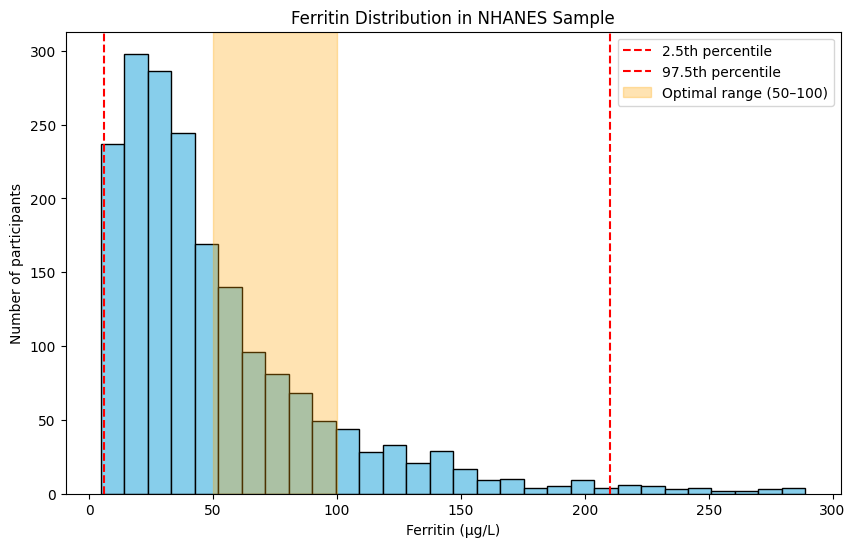

In [17]:
zoom_min = f_sample.quantile(0.01)
zoom_max = f_sample.quantile(0.99)

plt.figure(figsize=(10,6))
plt.hist(f_sample, bins=30, range=(zoom_min, zoom_max),
         color='skyblue', edgecolor='black')

plt.axvline(lower, color='red', linestyle='--', label='2.5th percentile')
plt.axvline(upper, color='red', linestyle='--', label='97.5th percentile')
plt.axvspan(50, 100, color='orange', alpha=0.3, label='Optimal range (50–100)')

plt.xlabel('Ferritin (µg/L)')
plt.ylabel('Number of participants')
plt.title('Ferritin Distribution in NHANES Sample')
plt.legend()
plt.show()

In [18]:
demo = pd.read_sas("/content/DEMO_L.xpt")

merged = pd.merge(
    ferritin_df[['SEQN', 'LBDFERSI', 'WTPH2YR']],
    demo[['SEQN', 'RIDAGEYR', 'RIAGENDR']],
    on='SEQN',
    how='inner'
)

women_18_49 = merged[
    (merged['RIAGENDR'] == 2) &
    (merged['RIDAGEYR'] >= 18) &
    (merged['RIDAGEYR'] <= 49)
]

f_women = women_18_49['LBDFERSI']
w_women = women_18_49['WTPH2YR'] #w=weight


In [19]:
women_18_49.shape

(1467, 5)

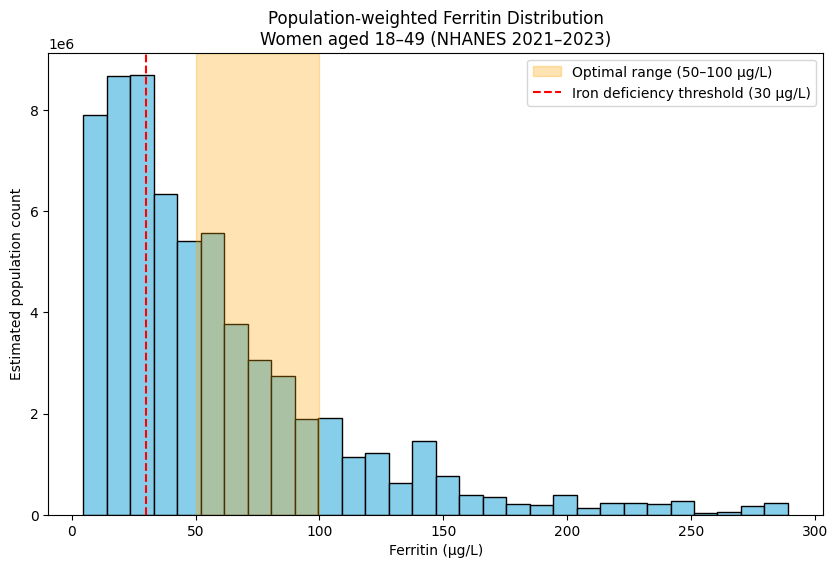

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    f_women,
    bins=30,
    weights=w_women,
    range=(zoom_min, zoom_max),
    edgecolor='black',
    color='skyblue'
)

# Optimal ferritin range
plt.axvspan(50, 100, color='orange', alpha=0.3,
            label='Optimal range (50–100 µg/L)')

# Reference threshold (iron deficiency)
plt.axvline(30, color='red', linestyle='--',
            label='Iron deficiency threshold (30 µg/L)')

plt.xlabel('Ferritin (µg/L)')
plt.ylabel('Estimated population count')
plt.title('Population-weighted Ferritin Distribution\nWomen aged 18–49 (NHANES 2021–2023)')
plt.legend()
plt.show()


## 2. Data and Methods

Data were obtained from NHANES 2021–2023.

The full ferritin dataset included n = 2,564 participants, spanning multiple age groups, including children aged 1–5 years and women aged 12–49 years.

For this analysis, the focus was restricted to **women aged 18–49**, resulting in a final analytical sample of **n = 1,467** women with available ferritin measurements.

NHANES sampling weights (WTPH2YR) were applied to estimate population-level percentages for US women aged 18–49.

Ferritin values were categorized into descriptive ranges:


*   &lt; 30 µg/L
*   30–50 µg/L
*   50–100 µg/L
*   &gt; 100 µg/L (for the purposes of this analysis, values above 100 µg/L are grouped together, as further stratification is not necessary for the study focus)


These categories are interpretative and descriptive, not diagnostic. There is currently no universally agreed “optimal” ferritin threshold. While most clinical sources agree that ferritin levels should exceed 50 µg/L to indicate adequate iron stores, upper and optimal boundaries vary across literature (commonly cited ranges include 70, 90, or even 110 µg/L). Therefore, the ranges used here aim to provide a balanced and transparent stratification rather than impose rigid clinical cut-offs.

In [21]:
def weighted_percentage(condition, weights):
    return weights[condition].sum() / weights.sum() * 100

pct_def = weighted_percentage(f_women < 30, w_women)
pct_low = weighted_percentage((f_women >= 30) & (f_women < 50), w_women)
pct_opt = weighted_percentage((f_women >= 50) & (f_women <= 100), w_women)
pct_higher = weighted_percentage((f_women > 100), w_women)

print(f"Ferritin < 30 µg/L: {pct_def:.1f}% - Iron deficiency / depleted stores")
print(f"Ferritin 30–50 µg/L: {pct_low:.1f}% - Low iron stores")
print(f"Ferritin 50–100 µg/L: {pct_opt:.1f}% - Optimal Range")
print(f"Ferritin >100 µg/L: {pct_higher:.1f}% - Above main study focus")



Ferritin < 30 µg/L: 33.4% - Iron deficiency / depleted stores
Ferritin 30–50 µg/L: 20.6% - Low iron stores
Ferritin 50–100 µg/L: 27.3% - Optimal Range
Ferritin >100 µg/L: 16.2% - Above main study focus


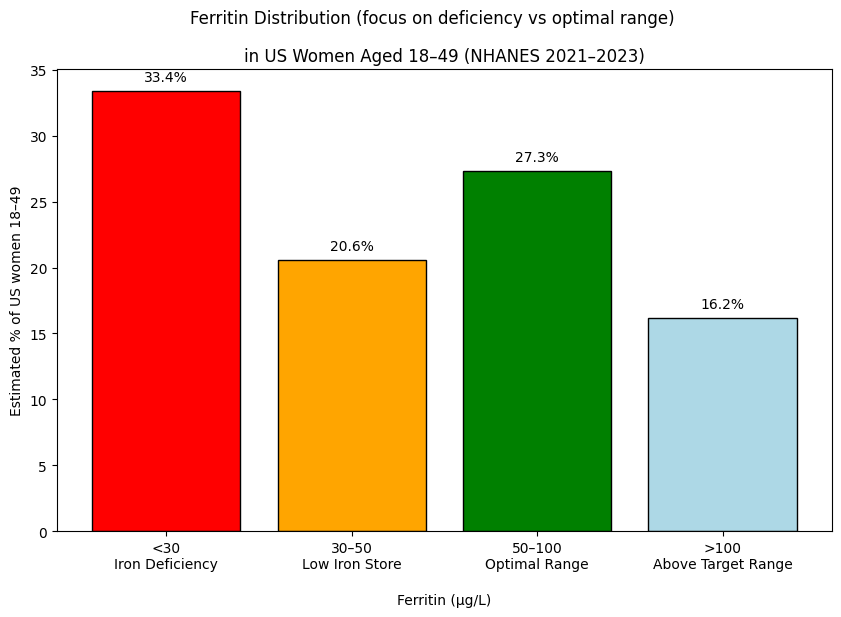

In [22]:
bins = [0, 30, 50, 100, float('inf')]
labels = ['<30\nIron Deficiency', '30–50\nLow Iron Store', '50–100\nOptimal Range', '>100\nAbove Target Range']

# Weights for each category
pct_values = [
    weighted_percentage(f_women < 30, w_women),
    weighted_percentage((f_women >= 30) & (f_women < 50), w_women),
    weighted_percentage((f_women >= 50) & (f_women <= 100), w_women),
    weighted_percentage((f_women > 100), w_women)
]

# Colours for bins
colors = ['red', 'orange', 'green', 'lightblue']

plt.figure(figsize=(10,6))
bars = plt.bar(labels, pct_values, color=colors, edgecolor='black')

# Adding percentage above bins
for bar, pct in zip(bars, pct_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.xlabel('\nFerritin (µg/L)')
plt.ylabel('Estimated % of US women 18–49')
plt.suptitle('Ferritin Distribution (focus on deficiency vs optimal range)')
plt.title('in US Women Aged 18–49 (NHANES 2021–2023)' )
plt.show()


## 3. Results

In the weighted population of US women aged 18–49, A large proportion of individuals fall below the optimal range, suggesting that suboptimal iron stores may be more common than expected.

33.4% had ferritin below 30 µg/L
(consistent with depleted iron stores)

20.6% had ferritin 30–50 µg/L
(low iron stores)

27.3% had ferritin 50–100 µg/L
(adequate / commonly referenced optimal range)

16.2% had ferritin above 100 µg/L (outside the target range and not the focus of this analysis).

These results indicate that **over half of US women aged 18–49 have ferritin levels below 50 µg/L**, a threshold widely considered necessary for sufficient iron stores.

## 4. Interpretation and Conclusion

This analysis suggests that a substantial proportion of women of reproductive age in the United States may have low or borderline iron stores, even if they do not meet strict laboratory criteria for iron deficiency.

Importantly, laboratory lower reference limits are based on statistical population distributions rather than physiological adequacy. As such, reliance solely on laboratory reference cut-offs may underestimate the prevalence of suboptimal iron status.

While this analysis applies NHANES sampling weights to estimate population percentages, it does not account for complex survey design elements such as stratification and clustering.

Further research is warranted to explore the clinical implications of these findings and to evaluate whether current reference standards sufficiently reflect functional iron needs in women of reproductive age.

## 5. References

WHO. (2021). Ferritin Guidelines Brochure. Retrieved from https://www.who.int/docs/default-source/micronutrients/ferritin-guideline/ferritin-guidelines-brochure.pdf?sfvrsn=76a71b5a_4

Centers for Disease Control and Prevention (CDC). National Health and Nutrition Examination Survey (NHANES) 2021–2023: Documentation and Datasets. Available at: https://www.cdc.gov/nchs/nhanes/index.htm

Accessed February 2026